<a href="https://colab.research.google.com/github/aayushchourasia123/Machine-Learning/blob/main/handling%20missing%20data2/arbitrary_value_imputation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [3]:
df=pd.read_csv('/content/titanic_toy.csv')
df

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0
...,...,...,...,...
886,27.0,13.0000,0,0
887,19.0,30.0000,0,1
888,NaN,23.4500,3,0
889,26.0,NaN,0,1


In [4]:
df.isnull().mean()*100

,0
Age,19.865320
Fare,5.050505
Family,0.000000
Survived,0.000000


In [5]:
x=df.drop(columns=['Survived'])
y=df['Survived']

In [6]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [7]:
x_train.shape,x_test.shape

((712, 3), (179, 3))

In [8]:
x_train['age_99']=x_train['Age'].fillna(99)
x_train['age_-1']=x_train['Age'].fillna(-1)

x_train['fare_999']=x_train['Fare'].fillna(999)
x_train['fare_-1']=x_train['Fare'].fillna(-1)

In [10]:
x_train.sample(5)

,Age,Fare,Family,age_99,age_-1,fare_999,fare_-1
807,18.0,7.7750,0,18.0,18.0,7.7750,7.7750
375,NaN,82.1708,1,99.0,-1.0,82.1708,82.1708
151,22.0,66.6000,1,22.0,22.0,66.6000,66.6000
727,NaN,7.7375,0,99.0,-1.0,7.7375,7.7375
307,17.0,108.9000,1,17.0,17.0,108.9000,108.9000


In [11]:
print('original age variance',x_train['Age'].var())
print('age 99 variance',x_train['age_99'].var())
print('age -1 variance',x_train['age_-1'].var())

print('original fare variance',x_train['Fare'].var())
print('fare 999 variance',x_train['fare_999'].var())
print('fare -1 variance',x_train['fare_-1'].var())

original age variance 204.3495133904614
age 99 variance 951.7275570187172
age -1 variance 318.0896202624484
original fare variance 2448.197913706318
fare 999 variance 47219.20265217623
fare -1 variance 2378.5676784883503


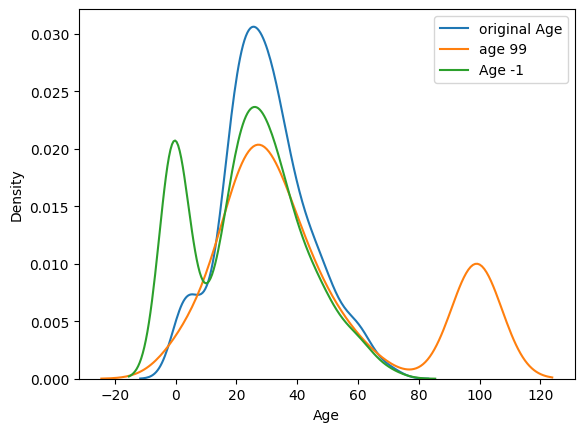

In [12]:
sns.kdeplot(x_train['Age'], label='original Age')
sns.kdeplot(x_train['age_99'], label='age 99')
sns.kdeplot(x_train['age_-1'], label='Age -1')
plt.legend()
plt.show()

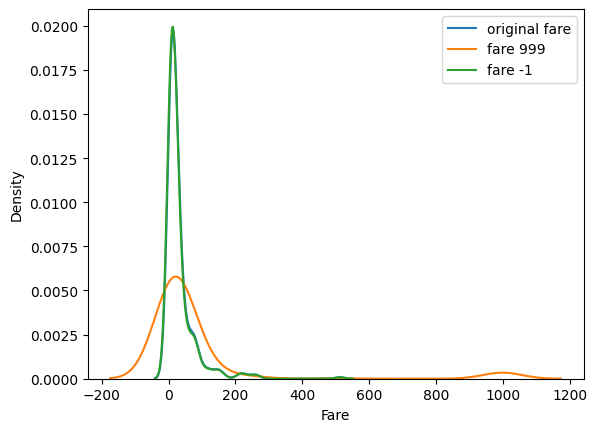

In [13]:
sns.kdeplot(x_train['Fare'], label='original fare')
sns.kdeplot(x_train['fare_999'], label='fare 999')
sns.kdeplot(x_train['fare_-1'], label='fare -1')
plt.legend()
plt.show()

In [14]:
x_train.cov()

,Age,Fare,Family,age_99,age_-1,fare_999,fare_-1
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,162.793430,63.321188
Fare,70.719262,2448.197914,17.258917,-101.671097,125.558364,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-7.387287,-4.149246,11.528625,16.553989
age_99,204.349513,-101.671097,-7.387287,951.727557,-189.535540,-159.931663,-94.317400
age_-1,204.349513,125.558364,-4.149246,-189.535540,318.089620,257.379887,114.394141
fare_999,162.793430,2448.197914,11.528625,-159.931663,257.379887,47219.202652,762.474982
fare_-1,63.321188,2448.197914,16.553989,-94.317400,114.394141,762.474982,2378.567678


In [15]:
x_train.corr()

,Age,Fare,Family,age_99,age_-1,fare_999,fare_-1
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.051179,0.084585
Fare,0.092644,1.000000,0.208268,-0.066273,0.142022,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.144787,-0.140668,0.032079,0.205233
age_99,1.000000,-0.066273,-0.144787,1.000000,-0.344476,-0.023857,-0.062687
age_-1,1.000000,0.142022,-0.140668,-0.344476,1.000000,0.066411,0.131514
fare_999,0.051179,1.000000,0.032079,-0.023857,0.066411,1.000000,0.071946
fare_-1,0.084585,1.000000,0.205233,-0.062687,0.131514,0.071946,1.000000


using sklearn

In [16]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [17]:
imputer1=SimpleImputer(strategy='constant',fill_value=99)
imputer2=SimpleImputer(strategy='constant',fill_value=999)

In [18]:
trf=ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [19]:
trf.fit(x_train)

/usr/local/lib/python3.11/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1',
                                 SimpleImputer(fill_value=99,
                                               strategy='constant'),
                                 ['Age']),
                                ('imputer2',
                                 SimpleImputer(fill_value=999,
                                               strategy='constant'),
                                 ['Fare'])])

In [20]:
trf.named_transformers_['imputer1'].statistics_

array([99.])

In [21]:
trf.named_transformers_['imputer2'].statistics_

array([999.])

In [22]:
x_train=trf.transform(x_train)
x_test=trf.transform(x_test)

In [23]:
x_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 99.    , 221.7792,   0.    ],
       [ 99.    ,  25.925 ,   0.    ]])